Raw AWS Data
     
     ↓

Phase A — Preprocessing
     
     ↓

Phase B — Physics Configuration
     
     ↓

Phase C — Physics Engine
     
     ↓

Phase D — Statistical / Multivariate
     
     ↓

Phase E — Thermodynamic
     
     ↓

Phase F — Temporal Engine
     
     ↓

Phase G — Evidence Normalization
     
     ↓
     
Physics + Temporal Evidence Score [0,1]

In [184]:
import pandas as pd
import numpy as np
import json #Importing important lib

#Input and Output file path
IP = "/content/drive/MyDrive/skyguard_weather.csv"
OP = "/content/physics_config.json"

Reference_Fraction=0.80 #Using first 80% of data for making and validate on rest 20
 #80% reference data and 20% holdout period.
#Global limits
Temp_Global_Min= -50.0
Temp_Global_Max= 60.0
Rh_Global_Min= 0.0
Rh_Global_Max= 100.0
P_Global_Min= 300.0
P_Global_Max= 1100.0
Temp_Cluster_Buffer= 4.0 #Giving some margin in each cluster/region
Temp_Station_Buffer= 2.0 #Station wise margin
P_Tolerance_Min= 15.0 #Pressure Tolerance will be more than 15 (not being too restrictive)
#Tolerance=max(15,calculated)
P_Mad_Factor= 6.0 #Mean absolute Deviation factor
# Tolerance=max(15,6*1.4826*MAD)


def load_data(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lower() #removing space and make them lowercase
    df["station_id"] = df["station_id"].astype(str).str.strip() #making station id as string
    df["timestamp"] = pd.to_datetime(df["timestamp"],errors="coerce",utc=True)
    #Time date conversion by pandas (coerce as it will not make crash if date and time cannot be created)

    for col in ["temperature_c", "humidity_pct", "pressure_hpa"]:
        #convert to numeric form if string or something
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df.sort_values(["timestamp", "station_id"]).reset_index(drop=True)
    #Sorted dataframe


def robust_bounds(series, low=0.01, high=0.99): #percentiles (JEE :))
    #help to reduce extereme observations
    x = series.dropna() #Removing Nan
    if x.empty:
        return None, None #If empty -> safely exit

    return(float(x.quantile(low)),float(x.quantile(high)))
    #Robust operating range (1 to 99 percentile)


def chronological_reference_split(df, fraction=0.80):
    timestamps = (df["timestamp"].dropna().drop_duplicates().sort_values().reset_index(drop=True)) #Removing invids and sorting timestamps
    cutoff_index = int(len(timestamps) * fraction) #taking only 80% index
    cutoff_index = min(max(cutoff_index, 1),len(timestamps) - 1) #Protect layer  , might cutoff index become 0 in above
    cutoff_timestamp = timestamps.iloc[cutoff_index] #New partioned timestamp
    reference = df[df["timestamp"]<cutoff_timestamp].copy() #80%
    holdout = df[df["timestamp"] >= cutoff_timestamp].copy() #rest 20%
    return reference, holdout, cutoff_timestamp


def build_physics_config(df, output_path):
    df = df.sort_values("timestamp").reset_index(drop=True) #sorting timestamps
    reference, _, cutoff_timestamp = chronological_reference_split(df,Reference_Fraction) #80% fraction
    config = {
        "config_version": "1.0", #Version to distinguish new and old data
        "reference_fraction": Reference_Fraction, #fraction
        "reference_start": reference["timestamp"].min().isoformat(), #start date of reference data
        "reference_end": reference["timestamp"].max().isoformat(), #last date of reference data
        "holdout_start": cutoff_timestamp.isoformat(), #begining of holdout period
        "global_rules": { #assigning global rules
            "temperature_min_c": Temp_Global_Min,
            "temperature_max_c": Temp_Global_Max,
            "humidity_min_pct": Rh_Global_Min,
            "humidity_max_pct": Rh_Global_Max,
            "pressure_min_hpa": P_Global_Min,
            "pressure_max_hpa": P_Global_Max},
        "cluster_rules": {},"station_rules": {}} #cluster /region and station will be empty till now


    cluster_groups = reference.groupby("cluster") #grouping as per cluster/region
    for cluster, group in cluster_groups:
        t_min, t_max = robust_bounds(group["temperature_c"]) #(1 and 99 percentile)
        if t_min is None:
            continue
        config["cluster_rules"][str(cluster)] = {
            "temperature_min_c": round(max(Temp_Global_Min, t_min - Temp_Cluster_Buffer), 2), #dataset might have anomaly
            "temperature_max_c": round(min(Temp_Global_Max, t_max + Temp_Cluster_Buffer), 2)}

    station_groups = reference.groupby("station_id") #groupby as per station
    for station_id, group in station_groups:
        t_min, t_max = robust_bounds(group["temperature_c"])
        pressure = group["pressure_hpa"].dropna() #p not matter much in cluster so only using in station
        if pressure.empty:
            continue
        p_median = float(pressure.median())
        mad = float(np.median(np.abs(pressure - p_median))) #Mean absolute deviation
        pressure_tolerance = max(P_Tolerance_Min,P_Mad_Factor * 1.4826 * mad)
        station = group.iloc[0]
        rule = {
            "station_name": str(station["station_name"]),
            "city": str(station["city"]),
            "cluster": str(station["cluster"]),
            "latitude": float(station["latitude"]),
            "longitude": float(station["longitude"]),
            "pressure_baseline_hpa": round(p_median, 2),
            "pressure_tolerance_hpa": round(pressure_tolerance, 2)}
        if t_min is not None:
            rule["temperature_min_c"] = round(
                max(Temp_Global_Min, t_min - Temp_Station_Buffer),2)
            rule["temperature_max_c"] = round(
                min(Temp_Global_Max, t_max + Temp_Station_Buffer),2)
        config["station_rules"][str(station_id)] = rule

#Making JSON File
    with open(output_path, "w") as f:
        json.dump(config, f, indent=2)
    return config

#Loading data with some preprocess
df = load_data(IP)
#JSON file physics config work
physics_config = build_physics_config(df,OP)

                 GLOBAL
        ┌─────────────────────┐
        │ T: -50 → 60°C       │
        │ RH: 0 → 100%        │
        │ P: 300 → 1100 hPa   │
        └──────────┬──────────┘
                   ↓
                CLUSTER
        ┌─────────────────────┐
        │ Regional T envelope │
        └──────────┬──────────┘
                   ↓
                STATION
        ┌─────────────────────┐
        │ Local T envelope    │
        │ P baseline          │
        │ P tolerance         │
        └─────────────────────┘
        

In [185]:
df

,cluster,station_id,station_name,city,latitude,longitude,timestamp,temperature_c,humidity_pct,pressure_hpa
0,NCR,42139,Meerut,Meerut,29.0167,77.6333,2024-01-01 00:00:00+00:00,5.9,100.0,1018.6
1,NCR,42181,New Delhi / Palam,Gurugram,28.5667,77.1167,2024-01-01 00:00:00+00:00,12.2,81.0,1019.4
2,NCR,42182,New Delhi / Safdarjung,Delhi,28.5833,77.2000,2024-01-01 00:00:00+00:00,10.8,95.0,1018.9
3,Central_UP,42189,Bareilly,Bareilly,28.3667,79.4000,2024-01-01 00:00:00+00:00,10.6,87.0,1018.9
4,NCR,42260,Agra,Agra,27.1500,77.9667,2024-01-01 00:00:00+00:00,10.3,100.0,1018.4
...,...,...,...,...,...,...,...,...,...,...
459404,Konkan_Deccan,43063,Poona,Pune,18.5333,73.8500,2026-08-24 10:00:00+00:00,27.0,72.0,1007.5
459405,Tamil_Nadu_Coast,43278,Madras,Chennai,13.0667,80.2500,2026-08-24 10:00:00+00:00,29.9,73.0,1005.1
459406,Tamil_Nadu_Coast,43279,Madras / Minambakkam,Tiruvallur,13.0000,80.1833,2026-08-24 10:00:00+00:00,32.3,62.0,1005.8
459407,Tamil_Nadu_Coast,43303,Vellore,Vellore,12.9167,79.1500,2026-08-24 10:00:00+00:00,30.2,68.0,1005.3


In [186]:
path= "/content/physics_config.json"

#Defining jsonfile to later on use in Physics engine
with open(path, "r") as f:
  PHYSICS_CONFIG = json.load(f)

Physics Engine

      Work

physics_config.json


       ↓


PhysicsEngine
       
       ↓


Incoming observation
       
       ↓

Check global rules
Check station rules
Check cluster rules
       
       
       ↓


Collect violated rules
       
       
       ↓

       
Return physics evidence


In [188]:
class PhysicsEngine:
    def __init__(self, config):
        self.config = config  #storing entire config in self object
        self.global_rules = config["global_rules"]  #extracting global,cluster,station rules
        self.cluster_rules = config["cluster_rules"]
        self.station_rules = config["station_rules"]

    def _station_rule(self, station_id):
        return self.station_rules.get(str(station_id))
      # Helper function, so on giving station id, we get all its rules like temp.pressure....


    def _cluster_rule(self, cluster):
        return self.cluster_rules.get(str(cluster))
      #Same helper function


    def evaluate(self, observation): #Receive a observation /Single data
        station_id = str(observation["station_id"]) #Extract everything from it
        cluster = str(observation["cluster"])
        temperature = observation["temperature_c"]
        humidity = observation["humidity_pct"]
        pressure = observation["pressure_hpa"]
        station_rule = self._station_rule(station_id) #Finding station specific rules
        cluster_rule = self._cluster_rule(cluster) #Cluster rules
        rules = {} #Result of every rules
        violated_rules = [] #Violated List Ex=violated_rules:["temperature_station"]
        temp_global = (temperature < self.global_rules["temperature_min_c"]or temperature > self.global_rules["temperature_max_c"])
        rules["temperature_global"] = {"violated": bool(temp_global),"value": temperature,
            "min": self.global_rules["temperature_min_c"],
            "max": self.global_rules["temperature_max_c"]}
        #checking for temp globally by boolean
        if temp_global:
            violated_rules.append("temperature_global")
        #Samelogic for Relative Humdity
        rh_violation = (humidity < self.global_rules["humidity_min_pct"]or humidity > self.global_rules["humidity_max_pct"])
        rules["humidity_global"] = {"violated": bool(rh_violation),"value": humidity,
            "min": self.global_rules["humidity_min_pct"],
            "max": self.global_rules["humidity_max_pct"]}
        #Forming boolean
        if rh_violation:
            violated_rules.append("humidity_global")
        #Same work for pressure global (Samjh jao bhaiyo/beheno)
        pressure_global = (
            pressure < self.global_rules["pressure_min_hpa"]
            or pressure > self.global_rules["pressure_max_hpa"]
        )
        rules["pressure_global"] = {
            "violated": bool(pressure_global),
            "value": pressure,
            "min": self.global_rules["pressure_min_hpa"],
            "max": self.global_rules["pressure_max_hpa"]
        }
        if pressure_global:
            violated_rules.append("pressure_global")

        if station_rule is not None:
          #Same work :)
            if "temperature_min_c" in station_rule:
                temp_station = (temperature < station_rule["temperature_min_c"]or temperature > station_rule["temperature_max_c"])

                rules["temperature_station"] = {"violated": bool(temp_station),"value": temperature,
                    "min": station_rule["temperature_min_c"],
                    "max": station_rule["temperature_max_c"]}

                if temp_station:
                    violated_rules.append("temperature_station")
            #Different approach in pressure_stationwise as we have MAD for each station so every station has different pressure tolerance
            pressure_min = (station_rule["pressure_baseline_hpa"]- station_rule["pressure_tolerance_hpa"])
            pressure_max = (station_rule["pressure_baseline_hpa"]+ station_rule["pressure_tolerance_hpa"])

            pressure_station = (pressure < pressure_min or pressure > pressure_max)

            rules["pressure_station"] = {"violated": bool(pressure_station),"value": pressure,
                "baseline": station_rule["pressure_baseline_hpa"],
                "tolerance": station_rule["pressure_tolerance_hpa"],
                "min": pressure_min,"max": pressure_max}

            if pressure_station:
                violated_rules.append("pressure_station")
        #Same thing for cluster again, aab tak toh samjh hi gaye hoge yaar :-)
        if cluster_rule is not None:
            temp_cluster = (temperature < cluster_rule["temperature_min_c"]or temperature > cluster_rule["temperature_max_c"])

            rules["temperature_cluster"] = {
                "violated": bool(temp_cluster),"value": temperature,
                "min": cluster_rule["temperature_min_c"],"max": cluster_rule["temperature_max_c"]}

            if temp_cluster:
                violated_rules.append("temperature_cluster")

        return {
            "station_id": station_id,
            "timestamp": observation.get("timestamp"),
            "rules": rules,
            "violated_rules": violated_rules,
            "physics_violation_count": len(violated_rules)
        }

In [189]:
physics_engine = PhysicsEngine(PHYSICS_CONFIG)

In [192]:
#Just checking how will be result shown

observation = {
    "station_id": "42139",
    "cluster": "NCR",
    "timestamp": "2026-01-01T00:00:00Z",
    "temperature_c": 25.0,
    "humidity_pct": 60.0,
    "pressure_hpa": 1150.0
}

result = physics_engine.evaluate(observation)

In [193]:
result

{'station_id': '42139',
 'timestamp': '2026-01-01T00:00:00Z',
 'rules': {'temperature_global': {'violated': False,
   'value': 25.0,
   'min': -50.0,
   'max': 60.0},
  'humidity_global': {'violated': False,
   'value': 60.0,
   'min': 0.0,
   'max': 100.0},
  'pressure_global': {'violated': True,
   'value': 1150.0,
   'min': 300.0,
   'max': 1100.0},
  'temperature_station': {'violated': False,
   'value': 25.0,
   'min': 4.0,
   'max': 43.2},
  'pressure_station': {'violated': True,
   'value': 1150.0,
   'baseline': 1009.5,
   'tolerance': 57.82,
   'min': 951.68,
   'max': 1067.32},
  'temperature_cluster': {'violated': False,
   'value': 25.0,
   'min': 3.0,
   'max': 45.6}},
 'violated_rules': ['pressure_global', 'pressure_station'],
 'physics_violation_count': 2}

Statistical Configuration work
(Later help us to calculate robust z- score for our parameters)

In [202]:
Stat_Z_Threshold= 3.0
Stat_Mad_Factor= 3.0
Min_Stat_Samples= 30

In [203]:
def build_statistical_config(df):
    reference, _, _ = chronological_reference_split(df,Reference_Fraction) #Taking 80% as refernce
    config = {
        "config_version": "1.0", #Telling the version of file
        #You already know in above blocks
        "reference_start": reference["timestamp"].min().isoformat(),
        "reference_end": reference["timestamp"].max().isoformat(),
        "station_rules": {},"cluster_rules": {}
    }
    #features on which stat based analysis will happen
    features = ["temperature_c","humidity_pct","pressure_hpa"]
    for station_id, group in reference.groupby("station_id"):
        rule = {} #empty dictionary
        for feature in features:
            values = group[feature].dropna() #drop Nan values
            if len(values) < Min_Stat_Samples:
              #Main point= if station has less samples then stats based analysis should not be considered as low amount of data
                continue

            median = float(values.median())
            #why median not mean-> making a robust stats function
            mad = float(np.median(np.abs(values - median)))
            #mediain absolute error
            scale = 1.4826*mad
            if scale <= 0: #Special cases-> if median absolute deviation=0
                scale = float(values.std()) #use std deviation as backup
            if scale <= 0 or np.isnan(scale):
              #if still zero->drop
                continue
            rule[feature] = {"median": round(median, 4),"scale": round(scale, 4),"threshold": Stat_Z_Threshold}
            #storing the parameters features(median,scale....)
            #later will be used as (x-median)/scale and then find z>3 or not i.e. threshold
        if rule:
            config["station_rules"][str(station_id)] = rule #attaching stats rule to config
    for cluster, group in reference.groupby("cluster"):
        #Complete same work (Ab na samjha raha main :())
        rule = {}
        for feature in features:
            values = group[feature].dropna()
            if len(values) < Min_Stat_Samples:
                continue
            median = float(values.median())
            mad = float(np.median(np.abs(values - median)))
            scale = 1.4826 * mad
            if scale <= 0:
                scale = float(values.std())
            if scale <= 0 or np.isnan(scale):
                continue
            rule[feature] = {"median": round(median, 4),"scale": round(scale, 4),"threshold": Stat_Z_Threshold}
        if rule:
            config["cluster_rules"][str(cluster)] = rule
    return config

In [206]:
STAT_CONFIG_PATH = "/content/statistical_config.json"
statistical_config = build_statistical_config(df)
with open(STAT_CONFIG_PATH, "w") as f:
    json.dump(statistical_config,f,indent=2)
    #So we have to JSON file->1) physics_config 2)statistics_config

Statistical Engine


In [209]:
class StatisticalEngine:
    def __init__(self, config):
        self.config = config #storing complete config in self.config
        self.station_rules = config["station_rules"] #Extraction
        self.cluster_rules = config["cluster_rules"]


    def _robust_z(self, value, rule):
      #Calculating Z (We already talked about it)
        median = rule["median"]
        scale = rule["scale"]
        if scale <= 0:
            return 0.0
        return abs(value - median) / scale


    def evaluate(self, observation): #Main function
        #if data comes (single observation)
        #Extract things from observations
        station_id = str(observation["station_id"])
        cluster = str(observation["cluster"])
        station_rule = self.station_rules.get(station_id)
        cluster_rule = self.cluster_rules.get(cluster)
        #Create a disctionary for bool result
        #List of violated rules
        results = {}
        violated_rules = []
        features = ["temperature_c","humidity_pct","pressure_hpa"]
        for feature in features:
            value = observation.get(feature)
            if pd.isna(value): #If nan toh fir skip kardenge
                continue
            station_result = None
            cluster_result = None
            if station_rule and feature in station_rule: #checking is that station and feature registered in config
                z = self._robust_z(value,station_rule[feature]) #checking z-score
                threshold = station_rule[feature]["threshold"] #threshold of z
                #Making station result
                station_result = {"value": value,"robust_z": round(z, 4),"threshold": threshold,"violated": bool(z > threshold)}
                if z > threshold:
                    #Append in list if violation
                    violated_rules.append(f"{feature}_station_statistical")
                #Same for cluster
            if cluster_rule and feature in cluster_rule:
                z = self._robust_z(value,cluster_rule[feature])
                threshold = cluster_rule[feature]["threshold"]
                cluster_result = {"value": value,"robust_z": round(z, 4),"threshold": threshold,"violated": bool(z > threshold)}
                if z > threshold:
                    violated_rules.append(f"{feature}_cluster_statistical")

            results[feature] = {"station": station_result,"cluster": cluster_result}

        return {"station_id": station_id,"timestamp": observation.get("timestamp"),"features": results,
            "violated_rules": violated_rules,"statistical_violation_count": len(violated_rules)}

In [212]:
with open(STAT_CONFIG_PATH, "r") as f:
    STATISTICAL_CONFIG = json.load(f)
statistical_engine = StatisticalEngine(STATISTICAL_CONFIG)

In [215]:
observation = {
    "station_id": "42139",
    "cluster": "NCR",
    "timestamp": "2026-01-01T00:00:00Z",
    "temperature_c": 55.0,
    "humidity_pct": 60.0,
    "pressure_hpa": 1005.0
}

statistical_result = statistical_engine.evaluate(observation)

In [216]:
statistical_result

{'station_id': '42139',
 'timestamp': '2026-01-01T00:00:00Z',
 'features': {'temperature_c': {'station': {'value': 55.0,
    'robust_z': 3.3393,
    'threshold': 3.0,
    'violated': True},
   'cluster': {'value': 55.0,
    'robust_z': 3.26,
    'threshold': 3.0,
    'violated': True}},
  'humidity_pct': {'station': {'value': 60.0,
    'robust_z': 0.5158,
    'threshold': 3.0,
    'violated': False},
   'cluster': {'value': 60.0,
    'robust_z': 0.5158,
    'threshold': 3.0,
    'violated': False}},
  'pressure_hpa': {'station': {'value': 1005.0,
    'robust_z': 0.467,
    'threshold': 3.0,
    'violated': False},
   'cluster': {'value': 1005.0,
    'robust_z': 0.4497,
    'threshold': 3.0,
    'violated': False}}},
 'violated_rules': ['temperature_c_station_statistical',
  'temperature_c_cluster_statistical'],
 'statistical_violation_count': 2}

Multivariete Config

Intial:- Temp , RH, Pressure seperately

Final:- Their combined result

In [217]:
#Required to create "Mahalanobis distance (discuss later)"
def build_multivariate_config(df):
    df = df.sort_values("timestamp").reset_index(drop=True) #Sort
    cutoff_index = int(len(df) * Reference_Fraction) #80%
    reference = df.iloc[:cutoff_index].copy()
    features = ["temperature_c","humidity_pct","pressure_hpa"]
    data = reference[features].dropna() #Remove Nan rows
    #Getting median,sclae and MAD
    median = data.median()
    mad = data.apply(lambda x: np.median(np.abs(x - np.median(x))))
    scale = 1.4826 * mad
    scale = scale.replace(0, np.nan)
    normalized = (data - median) / scale #Normalizing so that we can compare
    normalized = normalized.replace([np.inf, -np.inf],np.nan).dropna() #Dropping unwanted values like -infinty,infinty,Nan etc... (For Safety)
    #Covariance matrix (To understand their cmobination )
    covariance = np.cov(normalized.values,rowvar=False)
    covariance += np.eye(len(features)) * 1e-6 #Might some points are 0 so making sure they dont give unwanted values
    #Taking Inverse (Require in Mahalanobis distance)
    inverse_covariance = np.linalg.inv(covariance)

    return {"features": features,"median": median.to_dict(),"scale": scale.to_dict(),
        "inverse_covariance": inverse_covariance.tolist(),"threshold": 3.0}


            

    Historical AWS reference data

             ↓

      T / RH / Pressure
             
             ↓

       Robust median
             +
       Robust MAD scale
             
             ↓

       Normalize features
             
             ↓

     ┌─────────────────┐
     │ Covariance      │
     │ Matrix Σ        │
     └────────┬────────┘
              ↓
            Σ⁻¹
              
              ↓

      Multivariate config

In [218]:
MULTIVARIATE_CONFIG = build_multivariate_config(df)

    Incoming AWS observation
        │
        ▼
    [T, RH, Pressure]
        │
        ▼
    Check missing values
        │
        ├── Missing → available=False
        │
        ▼
    Subtract reference median
        │
        ▼
    Divide by robust scale
        │
        ▼
    Normalized vector Z
        │
        ▼
    Mahalanobis distance
        │
        ▼
    Compare with threshold
        │
        ├── D ≤ 3 → normal multivariate state
        │
        └── D > 3 → multivariate violation

In [221]:
class MultivariateStatisticalEngine:
    def __init__(self, config):
      #Extracting all data and sub-columns data and making them as array
        self.features = config["features"]
        self.median = np.array([config["median"][f]for f in self.features])
        self.scale = np.array([config["scale"][f]for f in self.features])
        self.inverse_covariance = np.array(config["inverse_covariance"])
        self.threshold = config["threshold"]


    def evaluate(self, observation):
        values = np.array([observation.get(f, np.nan) for f in self.features], dtype=float)
        if np.isnan(values).any(): #Checking any missing value
            return {"available": False,"mahalanobis_distance": None,"violated": False}
        scale = self.scale.copy()
        scale[scale == 0] = 1.0 #if sclae is 0 , make it 1 as it will make the problem (something/scale->infinty)
        #calculting for T,RH,P
        x = (values - self.median) / scale
        #Main point->Calculating Mahalanobis distance
        distance = np.sqrt(x.T @ self.inverse_covariance @ x)
        #Why not euclidena distance
        #Mahalanobis consider covariance so tell how they are different from normal weather considering
        #the combination of T,RH,P

        return {
            "available": True,"mahalanobis_distance": round(float(distance),4),
            "threshold": self.threshold,"violated": bool(distance > self.threshold)}

In [222]:
multivariate_engine = MultivariateStatisticalEngine(MULTIVARIATE_CONFIG)

Thermodynamic Engine
Categorized in small parts and then integrated

In [223]:
a= 17.625
b= 243.04
Dew_min_c = -80.0
Dew_max_c = 60.0
Dew_margin_c= 2.0

Magnus-Tetens Formula for Dew point


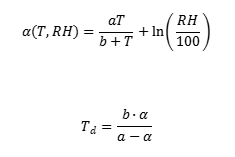

In [45]:
#Calculation of dew point by Megnus Tetans Equation
def calculate_dew_point(temperature_c, humidity_pct):
    if pd.isna(temperature_c) or pd.isna(humidity_pct):
        return np.nan
    if humidity_pct <= 0 or humidity_pct > 100:
        return np.nan
    gamma=(np.log(humidity_pct / 100.0)+ (a* temperature_c) / (b+ temperature_c))
    dew_point = (b* gamma)/(a- gamma)
    return float(dew_point)

             T + RH
               │
               ▼
      calculate_dew_point()
               │
               ▼
          Dew Point
               │
          ┌────┴────┐
          │         │
       Invalid    Valid
          │         │
          ▼         ▼
     available   Compare
       False      Td vs T + margin
                    │
              ┌─────┴─────┐
              │           │
           Normal      Violation
              │           │
              ▼           ▼
          violated      violated
           False          True

In [224]:
def check_dew_point_consistency(temperature_c,humidity_pct):
    #Calculate dew point by formula
    dew_point = calculate_dew_point(temperature_c,humidity_pct)
    if pd.isna(dew_point):
        #If Nan-> Exit
        return {"available": False,"violated": False,"dew_point_c": None}
    #Check the dewpoint-violation
    violation = (dew_point > temperature_c + Dew_margin_c)
    return {
        "available": True,"temperature_c": float(temperature_c),"humidity_pct": float(humidity_pct),
        "dew_point_c": round(dew_point, 4),"temperature_dewpoint_gap_c": round(float(temperature_c - dew_point),4),"violated": bool(violation)}

In [226]:
#Checking dewpoint is in range or not
def check_dew_point_range(dew_point):
    if pd.isna(dew_point):
        return {"available": False,"violated": False}
    violation = (dew_point < Dew_min_c or dew_point > Dew_max_c)
    return {
        "available": True,"dew_point_c": round(float(dew_point), 4),
        "min_c": Dew_min_c,"max_c": Dew_max_c,"violated": bool(violation)}

In [227]:
class ThermodynamicEngine:
    def evaluate(self, observation):
        #Getting data
        temperature = observation.get("temperature_c")
        humidity = observation.get("humidity_pct")
        result = {"station_id": str(observation.get("station_id")),"timestamp": observation.get("timestamp"),"rules": {},"violated_rules": []}
        #If Nan->Set False->Exit
        if pd.isna(temperature) or pd.isna(humidity):
            result["available"] = False
            result["thermodynamic_violation_count"] = 0
            return result
        #Calculate dewpoint, consistency and its range check
        dew_point = calculate_dew_point(temperature,humidity)
        consistency = check_dew_point_consistency(temperature,humidity)
        dew_point_range = check_dew_point_range(dew_point)
        #Update it in result rules section of respective columns
        result["rules"]["temperature_dewpoint_consistency"] = consistency
        result["rules"]["dewpoint_physical_range"] = dew_point_range
        #If violation happen->update it in result ->violated rules
        if consistency["violated"]:
            result["violated_rules"].append("temperature_dewpoint_consistency")
        if dew_point_range["violated"]:
            result["violated_rules"].append("dewpoint_physical_range")

        #Update the remaining things
        result["available"] = True
        result["dew_point_c"] = round(float(dew_point),4)
        result["thermodynamic_violation_count"] = len(result["violated_rules"])

        return result

In [228]:
thermodynamic_engine = ThermodynamicEngine()

In [233]:
MAX_TEMP_RATE_C_PER_MIN = 2.0
MAX_HUMIDITY_RATE_PCT_PER_MIN = 8.0
MAX_PRESSURE_RATE_HPA_PER_MIN = 2.0

MAX_TEMP_ACCELERATION_C_PER_MIN2 = 4.0
MAX_HUMIDITY_ACCELERATION_PCT_PER_MIN2 = 15.0
MAX_PRESSURE_ACCELERATION_HPA_PER_MIN2 = 4.0

FROZEN_WINDOW = 5
FROZEN_EPSILON = 1e-6

In [234]:
FROZEN_WINDOW = 5

FROZEN_EPSILON = {
    "temperature_c": 1e-3,
    "humidity_pct": 1e-3,
    "pressure_hpa": 1e-3
}
PERSISTENCE_WINDOW = 4
PERSISTENCE_MIN_VIOLATIONS = 3

In [235]:
#To calculate time difference features by taking present and previous value

def calculate_temporal_features(current, previous):
    if previous is None:
        return {"available": False}
    #Date-time conversion
    current_time = pd.to_datetime(current["timestamp"],utc=True)
    previous_time = pd.to_datetime(previous["timestamp"],utc=True)

    dt_seconds = (current_time - previous_time).total_seconds()
    if dt_seconds <= 0: #seconds cannot be negative
        return {"available": False}

    dt_minutes = dt_seconds / 60.0
    features = {"available": True,"dt_minutes": dt_minutes}

    #Calculating Rate in minutes if values are finite (means no error)
    for feature in ["temperature_c","humidity_pct","pressure_hpa"]:
        current_value = current.get(feature)
        previous_value = previous.get(feature)
        if pd.isna(current_value) or pd.isna(previous_value):
            features[feature] = {"delta": None,"rate": None}
            continue
        delta = (float(current_value)- float(previous_value))
        rate = delta / dt_minutes
        features[feature] = {"delta": delta,"rate": rate}

    return features

In [236]:
#Checking Rate is in range or not
def check_rate_of_change(temporal_features):
    if not temporal_features["available"]:
        return {"available": False,"violated_rules": []}
    thresholds = {
        "temperature_c":MAX_TEMP_RATE_C_PER_MIN,"humidity_pct":MAX_HUMIDITY_RATE_PCT_PER_MIN,"pressure_hpa":MAX_PRESSURE_RATE_HPA_PER_MIN}
    #Result Dictionary and violated rules list
    results = {}
    violated_rules = []
    for feature, threshold in thresholds.items():
        data = temporal_features.get(feature)
        if data is None or data["rate"] is None:
            continue
        rate = data["rate"]
        violated = abs(rate) > threshold
        results[feature] = {"rate": round(rate, 6),"threshold": threshold,"violated": bool(violated)}
        if violated:
            violated_rules.append(f"{feature}_rate")

    return {"available": True,"results": results,"violated_rules": violated_rules}

In [237]:
#Checking if the sensor is frozen  (continuos same rate for some window)
def check_frozen_sensor(history):
    if len(history) < FROZEN_WINDOW:
        return {"available": False,"results": {},"violated_rules": []}

    results = {}
    violated_rules = []
    for feature, epsilon in FROZEN_EPSILON.items():
        values = [obs.get(feature) for obs in history]
        #If Nan-> Skip that value
        if any(pd.isna(v) for v in values):
            continue
        variation = (max(values) - min(values))
        frozen = variation <= epsilon
        results[feature] = {"window": len(values),"variation": float(variation),"epsilon": epsilon,"violated": bool(frozen)}
        if frozen:
            violated_rules.append(f"{feature}_frozen")

    return {"available": True,"results": results,"violated_rules": violated_rules}

In [238]:
def check_persistence(temporal_history,rate_history):
    if len(rate_history) < PERSISTENCE_WINDOW:
        return {"available": False,"results": {},"violated_rules": []}

    recent_rates = rate_history[-PERSISTENCE_WINDOW:]
    thresholds = {"temperature_c":MAX_TEMP_RATE_C_PER_MIN,"humidity_pct":MAX_HUMIDITY_RATE_PCT_PER_MIN,"pressure_hpa":MAX_PRESSURE_RATE_HPA_PER_MIN}
    #Everything same as previous i.e. Dict and list-> take values-> check and compare->put in result
    results = {}
    violated_rules = []
    for feature, threshold in thresholds.items():
        rates = [item.get(feature)for item in recent_rates]
        rates = [rate for rate in rates if rate is not None]
        if len(rates) < PERSISTENCE_WINDOW:
            continue
        violating_steps = sum(abs(rate) > threshold for rate in rates)
        persistent = (violating_steps >=PERSISTENCE_MIN_VIOLATIONS)
        results[feature] = {"window": PERSISTENCE_WINDOW,"violating_steps": violating_steps,"required_violations":PERSISTENCE_MIN_VIOLATIONS,"violated": bool(persistent)}
        if persistent:
            violated_rules.append(f"{feature}_persistent")
    return {
        "available": True,"results": results,"violated_rules": violated_rules}

In [240]:
def calculate_acceleration(current_rate,previous_rate,dt_minutes):
    if (current_rate is None or previous_rate is None or dt_minutes <= 0):
        return None
    return (current_rate - previous_rate) / dt_minutes

In [241]:
def check_acceleration(current_features,previous_features):
    if (not current_features.get("available") or not previous_features.get("available")):
        return {"available": False,"results": {},"violated_rules": []}
    thresholds = {"temperature_c":MAX_TEMP_ACCELERATION_C_PER_MIN2,"humidity_pct": MAX_HUMIDITY_ACCELERATION_PCT_PER_MIN2,"pressure_hpa": MAX_PRESSURE_ACCELERATION_HPA_PER_MIN2}
    dt_minutes = current_features["dt_minutes"]
    results = {}
    violated_rules = []
    for feature, threshold in thresholds.items():
        current_data = current_features.get(feature)
        previous_data = previous_features.get(feature)
        if (current_data is None or previous_data is None or current_data["rate"] is None or previous_data["rate"] is None):
            continue
        acceleration = calculate_acceleration(current_data["rate"],previous_data["rate"],dt_minutes)
        violated = (abs(acceleration) > threshold)
        results[feature] = {"acceleration": round(acceleration,6),"threshold": threshold,"violated": bool(violated)}
        if violated:
            violated_rules.append(f"{feature}_acceleration")

    return {"available": True,"results": results,"violated_rules": violated_rules}

In [242]:
class TemporalEngine:
    def __init__(self):
      #Stores previous data
        self.previous_observations = {}
        self.previous_features = {}
        self.rate_history = {}
        self.observation_history = {}

    def evaluate(self, observation):
      #Extracting required things from the observation/data
        station_id = str(observation["station_id"])
        #Taking previous data
        previous_observation = (self.previous_observations.get(station_id))
        previous_features = (self.previous_features.get(station_id))
        #Calculate Time-related features like Rate
        temporal_features = calculate_temporal_features(observation,previous_observation)
        #Check result is in range or not
        rate_result = check_rate_of_change(temporal_features)
        #Check Rate of Rate
        acceleration_result = check_acceleration(temporal_features,previous_features)
        #Making a list of observed history
        observation_history = self.observation_history.setdefault(station_id,[])
        observation_history.append(observation.copy())

        #Set amount of windows are allowed (More is better but memory problem so...:) )
        if len(observation_history) > FROZEN_WINDOW:
            observation_history.pop(0)
        frozen_result = check_frozen_sensor(observation_history)
        station_rates = self.rate_history.setdefault(station_id,[])
        current_rates = {}
        for feature in ["temperature_c","humidity_pct","pressure_hpa"]:
            data = temporal_features.get(feature)
            current_rates[feature] = (None if data is None else data["rate"])

        station_rates.append(current_rates)
        if len(station_rates) > PERSISTENCE_WINDOW:
            station_rates.pop(0)

        persistence_result = check_persistence(None,station_rates)
        violated_rules = (rate_result["violated_rules"]
            + acceleration_result["violated_rules"] + frozen_result["violated_rules"]+ persistence_result["violated_rules"])
        evidence = {"rate_of_change": rate_result,"acceleration": acceleration_result,"frozen_sensor": frozen_result,
            "persistence": persistence_result}

        self.previous_observations[station_id] = observation.copy()
        self.previous_features[station_id] = temporal_features
        return {"station_id": station_id,"timestamp": observation.get("timestamp"),"available": temporal_features["available"],"evidence": evidence,
            "violated_rules": violated_rules,"temporal_violation_count": len(violated_rules)}

In [243]:
temporal_engine = TemporalEngine()

In [244]:
def evaluate_temporal_batch(data,engine):
    results = []
    for row in data.itertuples(index=False):
        observation = {"station_id": row.station_id,"cluster": row.cluster,"timestamp": row.timestamp,
                       "temperature_c": row.temperature_c,"humidity_pct": row.humidity_pct,"pressure_hpa": row.pressure_hpa}
        result = engine.evaluate(observation)
        results.append({"station_id": result["station_id"],"timestamp": result["timestamp"],"available": result["available"],"temporal_violation_count":result["temporal_violation_count"],
            "violated_rules":result["violated_rules"],"rate_of_change":result["evidence"]["rate_of_change"],
            "acceleration":result["evidence"]["acceleration"],"frozen_sensor":result["evidence"]["frozen_sensor"],"persistence":result["evidence"]["persistence"]})

    return results

In [245]:
def extract_temporal_features(result):
    rate = result["rate_of_change"].get("results",{})
    acceleration = result["acceleration"].get("results",{})
    frozen = result["frozen_sensor"].get("results",{})
    persistence = result["persistence"].get("results",{})
    output = {}
    for feature in ["temperature_c","humidity_pct","pressure_hpa"]:
        output[f"{feature}_rate"] = (rate.get(feature, {}).get("rate"))
        output[f"{feature}_rate_violation"] = (rate.get(feature, {}).get("violated", False))
        output[f"{feature}_acceleration"] = (acceleration.get(feature, {}).get("acceleration"))
        output[f"{feature}_acceleration_violation"] = (acceleration.get(feature, {}).get("violated", False))
        output[f"{feature}_frozen"] = (frozen.get(feature, {}).get("violated", False))
        output[f"{feature}_persistent"] = (persistence.get(feature, {}).get("violated", False))

    return pd.Series(output)

In [246]:
STREAM_INPUT = df.copy()
STREAM_INPUT["timestamp"] = pd.to_datetime(
    STREAM_INPUT["timestamp"],
    errors="coerce",
    utc=True
)
STREAM_INPUT = STREAM_INPUT.sort_values(
    ["timestamp", "station_id"]
).reset_index(drop=True)

In [247]:
stream_engine = TemporalEngine()

In [249]:
def evaluate_stream(data,engine,limit=None):
    results = []
    if limit is not None:
        data = data.iloc[:limit]
    for row in data.itertuples(index=False):
        observation = {"station_id": row.station_id,"cluster": row.cluster,"timestamp": row.timestamp,
            "temperature_c": row.temperature_c,"humidity_pct": row.humidity_pct,"pressure_hpa": row.pressure_hpa}
        result = engine.evaluate(observation)
        results.append(result)
    return results

In [250]:
stream_results = evaluate_stream(STREAM_INPUT,stream_engine,limit=100)

In [251]:
stream_results[-1]

{'station_id': '43331',
 'timestamp': Timestamp('2024-01-01 04:00:00+0000', tz='UTC'),
 'available': True,
 'evidence': {'rate_of_change': {'available': True,
   'results': {'temperature_c': {'rate': 0.05,
     'threshold': 2.0,
     'violated': False},
    'humidity_pct': {'rate': -0.233333, 'threshold': 8.0, 'violated': False},
    'pressure_hpa': {'rate': 0.001667, 'threshold': 2.0, 'violated': False}},
   'violated_rules': []},
  'acceleration': {'available': True,
   'results': {'temperature_c': {'acceleration': 0.000583,
     'threshold': 4.0,
     'violated': False},
    'humidity_pct': {'acceleration': -0.003889,
     'threshold': 15.0,
     'violated': False},
    'pressure_hpa': {'acceleration': -0.000222,
     'threshold': 4.0,
     'violated': False}},
   'violated_rules': []},
  'frozen_sensor': {'available': True,
   'results': {'temperature_c': {'window': 5,
     'variation': 4.600000000000001,
     'epsilon': 0.001,
     'violated': False},
    'humidity_pct': {'window'

In [252]:
stream_summary = pd.DataFrame([
    {
        "station_id": result["station_id"],
        "timestamp": result["timestamp"],
        "available": result["available"],
        "temporal_violation_count":
            result["temporal_violation_count"],
        "violated_rules":
            result["violated_rules"]
    }
    for result in stream_results
])

In [253]:
stream_summary.head(20)

,station_id,timestamp,available,temporal_violation_count,violated_rules
0,42139,2024-01-01 00:00:00+00:00,False,0,[]
1,42181,2024-01-01 00:00:00+00:00,False,0,[]
2,42182,2024-01-01 00:00:00+00:00,False,0,[]
3,42189,2024-01-01 00:00:00+00:00,False,0,[]
4,42260,2024-01-01 00:00:00+00:00,False,0,[]
5,42379,2024-01-01 00:00:00+00:00,False,0,[]
6,42475,2024-01-01 00:00:00+00:00,False,0,[]
7,42483,2024-01-01 00:00:00+00:00,False,0,[]
8,42709,2024-01-01 00:00:00+00:00,False,0,[]
9,42803,2024-01-01 00:00:00+00:00,False,0,[]


In [254]:
stream_test_engine = TemporalEngine()

stream_test_engine.evaluate({
    "station_id": "TEST",
    "cluster": "NCR",
    "timestamp": "2026-01-01T00:00:00Z",
    "temperature_c": 25.0,
    "humidity_pct": 60.0,
    "pressure_hpa": 1005.0
})

stream_test_engine.evaluate({
    "station_id": "TEST",
    "cluster": "NCR",
    "timestamp": "2026-01-01T00:01:00Z",
    "temperature_c": 25.5,
    "humidity_pct": 59.5,
    "pressure_hpa": 1004.8
})

realtime_test = stream_test_engine.evaluate({
    "station_id": "TEST",
    "cluster": "NCR",
    "timestamp": "2026-01-01T00:02:00Z",
    "temperature_c": 30.5,
    "humidity_pct": 45.0,
    "pressure_hpa": 1003.0
})

In [255]:
realtime_test

{'station_id': 'TEST',
 'timestamp': '2026-01-01T00:02:00Z',
 'available': True,
 'evidence': {'rate_of_change': {'available': True,
   'results': {'temperature_c': {'rate': 5.0,
     'threshold': 2.0,
     'violated': True},
    'humidity_pct': {'rate': -14.5, 'threshold': 8.0, 'violated': True},
    'pressure_hpa': {'rate': -1.8, 'threshold': 2.0, 'violated': False}},
   'violated_rules': ['temperature_c_rate', 'humidity_pct_rate']},
  'acceleration': {'available': True,
   'results': {'temperature_c': {'acceleration': 4.5,
     'threshold': 4.0,
     'violated': True},
    'humidity_pct': {'acceleration': -14.0,
     'threshold': 15.0,
     'violated': False},
    'pressure_hpa': {'acceleration': -1.6,
     'threshold': 4.0,
     'violated': False}},
   'violated_rules': ['temperature_c_acceleration']},
  'frozen_sensor': {'available': False, 'results': {}, 'violated_rules': []},
  'persistence': {'available': False, 'results': {}, 'violated_rules': []}},
 'violated_rules': ['temper

Score Calculation and Fusion

In [256]:
PHYSICS_RULE_SCALE = 3.0
THERMODYNAMIC_RULE_SCALE = 2.0
STATISTICAL_Z_SCALE = 3.0
MULTIVARIATE_DISTANCE_SCALE = 3.0
TEMPORAL_RATE_SCALE = 1.0
TEMPORAL_ACCELERATION_SCALE = 1.0

In [257]:
def evidence_score(magnitude, threshold, scale):
    if magnitude is None or pd.isna(magnitude):
        return 0.0
    excess = max(0.0,abs(float(magnitude)) - threshold)
    if excess <= 0:
        return 0.0
    score = excess / (excess + scale)
    return float(np.clip(score, 0.0, 1.0))

In [258]:
def rule_count_score(violation_count,scale):
    if violation_count <= 0:
        return 0.0
    score = 1.0 - np.exp(-violation_count / scale)
    return float(np.clip(score, 0.0, 1.0))

In [259]:
def statistical_evidence_score(statistical_result):
    scores = []
    features = statistical_result.get("features",{})
    for feature_data in features.values():
        for level in ["station","cluster"]:
            result = feature_data.get(level)
            if result is None:
                continue
            z = result.get("robust_z")
            threshold = result.get("threshold",STATISTICAL_Z_SCALE)
            if z is None:
                continue
            score = evidence_score(z,threshold,STATISTICAL_Z_SCALE)
            scores.append(score)
    if not scores:
        return 0.0
    return float(np.max(scores))

In [260]:
def multivariate_evidence_score(multivariate_result):
    if not multivariate_result.get("available",False):
        return 0.0

    distance = multivariate_result.get("mahalanobis_distance")
    threshold = multivariate_result.get("threshold",MULTIVARIATE_DISTANCE_SCALE)
    return evidence_score(distance,threshold,MULTIVARIATE_DISTANCE_SCALE)

In [261]:
def thermodynamic_evidence_score(thermodynamic_result):
    violation_count = thermodynamic_result.get("thermodynamic_violation_count",0)
    return rule_count_score(violation_count,THERMODYNAMIC_RULE_SCALE)

In [169]:
def physics_evidence_score(physics_result,statistical_result,multivariate_result,thermodynamic_result):
    absolute_score = rule_count_score(physics_result.get("physics_violation_count",0),PHYSICS_RULE_SCALE)
    statistical_score = statistical_evidence_score(statistical_result)
    multivariate_score = multivariate_evidence_score(multivariate_result)
    thermodynamic_score = thermodynamic_evidence_score(thermodynamic_result)

    component_scores = [absolute_score,statistical_score,multivariate_score,thermodynamic_score]

    return {"absolute": absolute_score,"statistical": statistical_score,"multivariate": multivariate_score,
            "thermodynamic": thermodynamic_score,"physics_score": float(np.max(component_scores))}

In [262]:
def temporal_evidence_score(temporal_result):
    scores = []
    evidence = temporal_result.get("evidence",{})
    rate_result = evidence.get("rate_of_change",{})
    acceleration_result = evidence.get("acceleration",{})
    frozen_result = evidence.get("frozen_sensor",{})
    persistence_result = evidence.get("persistence",{})
    rate_thresholds = {"temperature_c":MAX_TEMP_RATE_C_PER_MIN,
        "humidity_pct":MAX_HUMIDITY_RATE_PCT_PER_MIN,"pressure_hpa":MAX_PRESSURE_RATE_HPA_PER_MIN}

    for feature, threshold in rate_thresholds.items():
        result = rate_result.get("results",{}).get(feature)
        if result is None:
            continue
        score = evidence_score(result.get("rate"),threshold,TEMPORAL_RATE_SCALE)
        scores.append(score)
    acceleration_thresholds = {"temperature_c":MAX_TEMP_ACCELERATION_C_PER_MIN2,
"humidity_pct":MAX_HUMIDITY_ACCELERATION_PCT_PER_MIN2,"pressure_hpa":MAX_PRESSURE_ACCELERATION_HPA_PER_MIN2}

    for feature, threshold in acceleration_thresholds.items():
        result = acceleration_result.get("results",{}).get(feature)

        if result is None:
            continue
        score = evidence_score(result.get("acceleration"),threshold,TEMPORAL_ACCELERATION_SCALE)
        scores.append(score)
    if frozen_result.get("violated_rules"):
        scores.append(1.0)
    if persistence_result.get("violated_rules"):
        scores.append(1.0)
    temporal_score = (max(scores) if scores else 0.0)
    return {"temporal_score": float(np.clip(temporal_score,0.0,1.0))}

In [263]:
physics_result = physics_engine.evaluate(observation)
statistical_result = statistical_engine.evaluate(observation)
multivariate_result = multivariate_engine.evaluate(observation)
thermodynamic_result = thermodynamic_engine.evaluate(observation)

In [264]:
physics_scores = physics_evidence_score(physics_result,statistical_result,multivariate_result,thermodynamic_result)

In [265]:
physics_scores

{'absolute': 0.486582880967408,
 'statistical': 0.10160812146258202,
 'multivariate': 0.5302517850432168,
 'thermodynamic': 0.0,
 'physics_score': 0.5302517850432168}

In [266]:
temporal_scores = temporal_evidence_score(realtime_test)

In [267]:
temporal_scores

{'temporal_score': 0.8666666666666667}

In [268]:
PHYSICS_WEIGHT = 0.5 #Have ti change as per DS-Theory (0.5 is also good btw..)
TEMPORAL_WEIGHT = 0.5
def fuse_physics_temporal(physics_score, temporal_score):
    final_score = (PHYSICS_WEIGHT * physics_score + TEMPORAL_WEIGHT * temporal_score)
    return float(np.clip(final_score, 0.0, 1.0))

In [269]:
physics_score = physics_scores["physics_score"]
temporal_score = temporal_scores["temporal_score"]
physics_temporal_score = fuse_physics_temporal(physics_score,temporal_score)
physics_temporal_score

0.6984592258549418